# Bias and Variance

Bias and Variance are two fundamental concepts in Machine Learning that explain why a model makes prediction errors.

They help us understand:

- Why a model underfits
- Why a model overfits
- How model complexity affects performance
- Why training error and validation error behave differently
- How to choose an appropriate model complexity
- Why regularization can improve generalization

The central idea is the **Bias-Variance Tradeoff**.

A good machine learning model should have:

- Low enough bias to capture the underlying pattern
- Low enough variance to generalize to unseen data
- Low sensitivity to random noise

The goal is not to make a model perfectly fit the training data.

The goal is to build a model that performs well on **unseen data**.

## 1. What is Prediction Error?

Suppose the true relationship between input and output is:

$$
Y = f(X) + \epsilon
$$

where:

- $X$ = input features
- $Y$ = observed target
- $f(X)$ = true underlying relationship
- $\epsilon$ = random noise

A machine learning model learns an approximation:

$$
\hat{f}(X)
$$

The model's prediction is:

$$
\hat{Y} = \hat{f}(X)
$$

The prediction error is the difference between the actual value and the predicted value:

$$
Error = Y - \hat{Y}
$$

However, prediction error is not caused by only one factor.

It can come from:

1. Bias
2. Variance
3. Irreducible noise

Understanding these components is the foundation of the Bias-Variance Tradeoff.

## 2. Bias

**Bias** measures how far the average prediction of a model is from the true underlying function.

A model with high bias makes strong simplifying assumptions about the data.

For example:

- A linear model applied to a highly nonlinear problem
- A very shallow decision tree
- A model that is too simple to capture the underlying pattern

High bias usually causes **underfitting**.

Mathematically, the bias at a particular input $x$ can be written as:

$$
Bias(\hat{f}(x))
=
E[\hat{f}(x)] - f(x)
$$

where:

- $E[\hat{f}(x)]$ is the average prediction over many possible training datasets
- $f(x)$ is the true underlying function

The squared bias is:

$$
Bias^2
=
\left(E[\hat{f}(x)] - f(x)\right)^2
$$

A high-bias model consistently makes predictions that are systematically wrong.

### Intuition Behind Bias

Imagine training the same model many times using different training datasets.

If the model has high bias, its predictions will tend to be consistently far from the true value.

For example:

True function:

$$
f(x) = x^2
$$

Suppose we use a linear model:

$$
\hat{f}(x) = ax + b
$$

The linear model may consistently miss the curvature of the true function.

This systematic error is **bias**.

High bias means:

- Model is too simple
- Important patterns are missed
- Predictions are systematically inaccurate
- Training error is usually high
- Validation error is usually high

## Visualizing High Bias

A high-bias model is too simple to capture the underlying pattern.

This usually results in **underfitting**.

The model makes systematic errors and cannot follow the true relationship in the data.

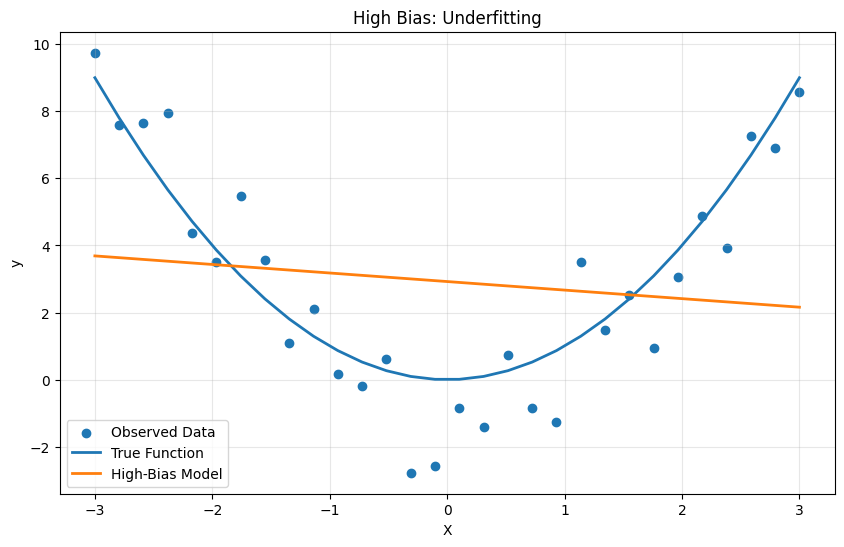

In [11]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Generate nonlinear data
X = np.linspace(-3, 3, 30)

y_true = X**2

y = y_true + np.random.normal(0, 1.5, size=len(X))

# Simple linear model
coefficients = np.polyfit(X, y, 1)
y_pred = np.polyval(coefficients, X)

plt.figure(figsize=(10, 6))

plt.scatter(
    X,
    y,
    label="Observed Data"
)

plt.plot(
    X,
    y_true,
    linewidth=2,
    label="True Function"
)

plt.plot(
    X,
    y_pred,
    linewidth=2,
    label="High-Bias Model"
)

plt.xlabel("X")
plt.ylabel("y")
plt.title("High Bias: Underfitting")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

What this shows

The true relationship is curved:

        True Function
           ∪
          / \
         /   \
--------/-----\--------
      Linear Model

The linear model cannot capture the nonlinear relationship.

Therefore:

High Bias
    ↓
Model too simple
    ↓
Underfitting

## 3. Variance

**Variance** measures how much a model's predictions change when the training dataset changes.

A high-variance model is highly sensitive to the particular training data it receives.

For a particular input $x$:

$$
Variance(\hat{f}(x))
=
E
\left[
\left(
\hat{f}(x) - E[\hat{f}(x)]
\right)^2
\right]
$$

A high-variance model can learn not only the underlying pattern but also random fluctuations and noise in the training data.

High variance usually causes **overfitting**.

Examples of models that can have high variance when insufficiently constrained:

- Very deep decision trees
- High-degree polynomial models
- Highly flexible models
- Models with too many parameters relative to the amount of training data

### Intuition Behind Variance

Imagine training the same model many times using different training datasets.

If the model has high variance, its predictions can change significantly depending on which training examples were included.

For example:

Training Dataset A → Model A

Training Dataset B → Model B

Training Dataset C → Model C

If Model A, B, and C make very different predictions for the same input, the model has high variance.

High variance means:

- Model is too complex
- Model learns training-specific patterns
- Model is sensitive to small changes in data
- Training error is usually very low
- Validation/test error can be high

## Visualizing High Variance

A high-variance model is excessively sensitive to the training data.

It can fit individual training points very closely and may also learn random noise.

This usually results in **overfitting**.

The model performs very well on training data but may perform poorly on unseen data.

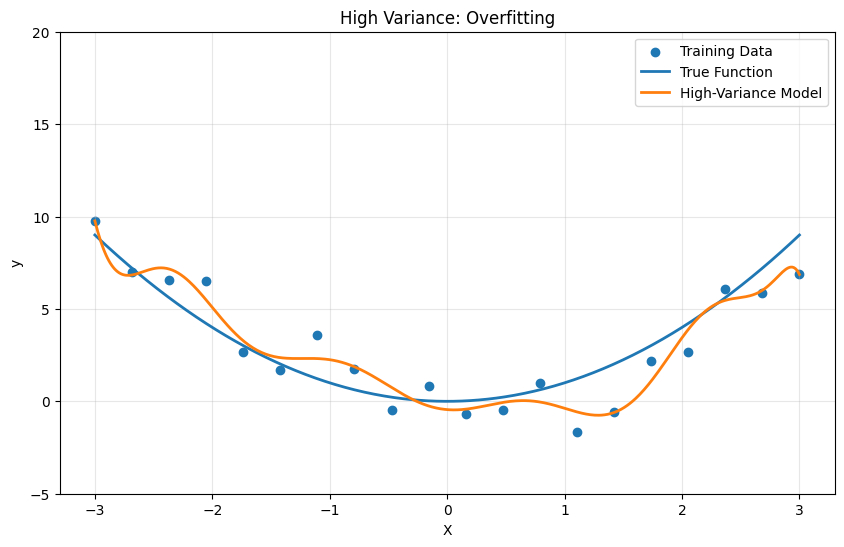

In [12]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Generate nonlinear data
X = np.linspace(-3, 3, 20)

y_true = X**2

y = y_true + np.random.normal(0, 1.5, size=len(X))

# High-degree polynomial model
degree = 12

coefficients = np.polyfit(X, y, degree)

X_smooth = np.linspace(-3, 3, 500)

y_pred = np.polyval(
    coefficients,
    X_smooth
)

plt.figure(figsize=(10, 6))

plt.scatter(
    X,
    y,
    label="Training Data"
)

plt.plot(
    X_smooth,
    X_smooth**2,
    linewidth=2,
    label="True Function"
)

plt.plot(
    X_smooth,
    y_pred,
    linewidth=2,
    label="High-Variance Model"
)

plt.xlabel("X")
plt.ylabel("y")
plt.title("High Variance: Overfitting")

plt.ylim(-5, 20)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

What this shows

The high-degree polynomial is flexible enough to follow individual training observations.

Instead of learning only:

Underlying pattern

it starts learning:

Underlying pattern + Random noise

    Therefore:

    High Variance
        ↓
    Model too flexible
        ↓
    Overfitting

## 4. Bias vs Variance

Bias and variance describe two different types of model behavior.

### High Bias

A high-bias model:

- Is too simple
- Makes strong assumptions
- Misses important relationships
- Underfits the data
- Has high training error
- Has high validation error

### High Variance

A high-variance model:

- Is very flexible
- Fits the training data extremely closely
- Can learn noise
- Overfits the data
- Has very low training error
- Has significantly higher validation/test error

A useful way to remember them:

**Bias → Model is too simple**

**Variance → Model is too sensitive**

## 5. Underfitting

Underfitting occurs when a model is too simple to learn the important structure in the data.

Typical characteristics:

- High training error
- High validation error
- High bias
- Usually relatively low variance

Example:

Suppose the true relationship is nonlinear:

$$
y = x^2
$$

If we use a simple linear model:

$$
y = ax + b
$$

the model may fail to capture the relationship.

This is an example of underfitting.

### How to reduce underfitting

Possible solutions include:

- Use a more complex model
- Add useful features
- Add nonlinear features
- Reduce excessive regularization
- Train the model for longer when appropriate

## 6. Overfitting

Overfitting occurs when a model learns the training data too closely, including patterns that do not generalize to new data.

Typical characteristics:

- Very low training error
- High validation/test error
- Low bias
- High variance

For example, a very high-degree polynomial may pass almost exactly through every training point.

However, the resulting function may behave poorly on unseen data.

### How to reduce overfitting

Common techniques include:

- Use a simpler model
- Collect more training data
- Apply regularization
- Reduce model complexity
- Perform feature selection
- Use cross-validation
- Use early stopping where applicable
- Remove noisy or irrelevant features

## 7. Bias-Variance Tradeoff

The **Bias-Variance Tradeoff** describes the relationship between model complexity, bias, and variance.

As model complexity increases:

- Bias generally decreases
- Variance generally increases

As model complexity decreases:

- Bias generally increases
- Variance generally decreases

The goal is to find a model complexity that gives a good balance between the two.

Conceptually:

$$
\text{Low Complexity}
\rightarrow
\text{High Bias, Low Variance}
$$

$$
\text{High Complexity}
\rightarrow
\text{Low Bias, High Variance}
$$

The best model is usually somewhere between these two extremes.

The objective is **low generalization error**, not simply low training error.

## Visualizing the Bias-Variance Tradeoff

As model complexity increases:

$$
Bias \downarrow
$$

$$
Variance \uparrow
$$

The total generalization error typically decreases at first and then increases.

The best model complexity lies near the point where the validation error is minimized.

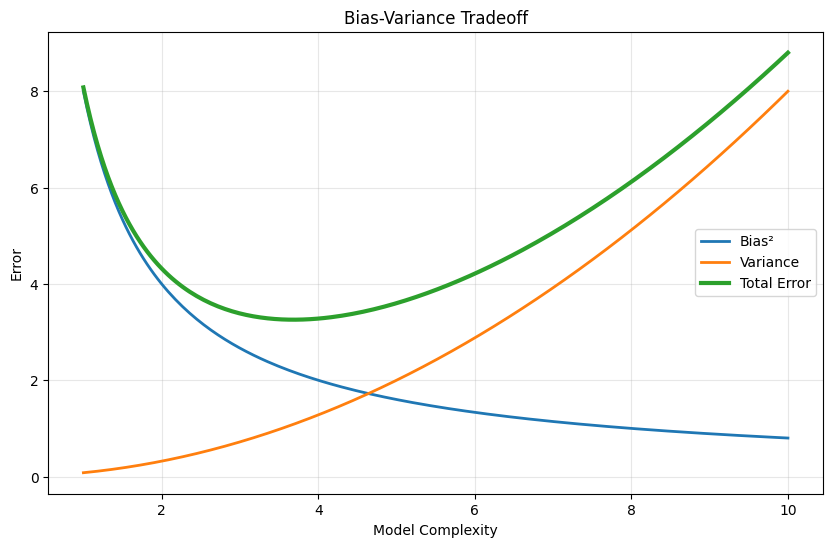

In [13]:
import numpy as np
import matplotlib.pyplot as plt

complexity = np.linspace(1, 10, 200)

# Illustrative bias and variance curves
bias_squared = 8 / complexity

variance = 0.08 * complexity**2

total_error = bias_squared + variance

plt.figure(figsize=(10, 6))

plt.plot(
    complexity,
    bias_squared,
    linewidth=2,
    label="Bias²"
)

plt.plot(
    complexity,
    variance,
    linewidth=2,
    label="Variance"
)

plt.plot(
    complexity,
    total_error,
    linewidth=3,
    label="Total Error"
)

plt.xlabel("Model Complexity")
plt.ylabel("Error")
plt.title("Bias-Variance Tradeoff")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 8. Bias-Variance Decomposition

For regression, the expected prediction error can be decomposed into:

$$
E[(Y-\hat{f}(x))^2]
=
Bias^2
+
Variance
+
Irreducible\ Noise
$$

More explicitly:

$$
E[(Y-\hat{f}(x))^2]
=
\left(E[\hat{f}(x)]-f(x)\right)^2
+
E\left[
\left(
\hat{f}(x)-E[\hat{f}(x)]
\right)^2
\right]
+
\sigma^2
$$

where:

- First term = Bias squared
- Second term = Variance
- Third term = Irreducible noise

Therefore:

$$
Total\ Error
=
Bias^2 + Variance + Noise
$$

This decomposition is one of the most important ideas in understanding model generalization.

## Var(X) = E(X^2) - [E(X)]^2

## 9. Irreducible Noise

Not every prediction error can be eliminated by choosing a better model.

Suppose:

$$
Y = f(X) + \epsilon
$$

where $\epsilon$ represents random noise.

Even if we knew the true function $f(X)$ perfectly, the random noise $\epsilon$ would still exist.

This is called **irreducible error**.

Therefore:

$$
Total\ Error
=
Bias^2 + Variance + Irreducible\ Noise
$$

We can reduce:

- Bias
- Variance

But we cannot completely remove irreducible noise from the data-generating process.

This is why achieving zero test error is generally impossible in real-world problems.

## 10. Model Complexity

Model complexity describes how flexible a model is.

A simple model has limited ability to represent complex relationships.

A complex model can represent a wider range of relationships.

Examples:

### Low Complexity

- Linear regression
- Shallow decision tree
- Low-degree polynomial

### High Complexity

- Deep decision tree
- High-degree polynomial
- Highly flexible neural network

As complexity increases:

$$
Bias \downarrow
$$

and generally:

$$
Variance \uparrow
$$

This creates the Bias-Variance Tradeoff.

However, the exact behavior depends on the dataset, model class, regularization, and amount of data.

## Highlight the Optimal Complexity

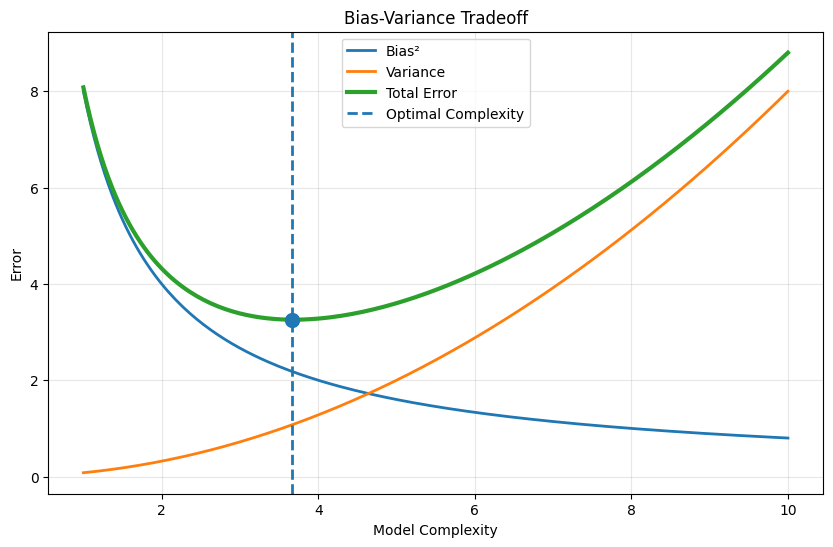

Optimal complexity: 3.67
Minimum total error: 3.26


In [14]:
import numpy as np
import matplotlib.pyplot as plt

complexity = np.linspace(1, 10, 200)

bias_squared = 8 / complexity

variance = 0.08 * complexity**2

total_error = bias_squared + variance

# Find the complexity with minimum total error
optimal_index = np.argmin(total_error)

optimal_complexity = complexity[optimal_index]
minimum_error = total_error[optimal_index]

plt.figure(figsize=(10, 6))

plt.plot(
    complexity,
    bias_squared,
    linewidth=2,
    label="Bias²"
)

plt.plot(
    complexity,
    variance,
    linewidth=2,
    label="Variance"
)

plt.plot(
    complexity,
    total_error,
    linewidth=3,
    label="Total Error"
)

plt.axvline(
    optimal_complexity,
    linestyle="--",
    linewidth=2,
    label="Optimal Complexity"
)

plt.scatter(
    optimal_complexity,
    minimum_error,
    s=100,
    zorder=5
)

plt.xlabel("Model Complexity")
plt.ylabel("Error")
plt.title("Bias-Variance Tradeoff")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

print("Optimal complexity:", round(optimal_complexity, 2))
print("Minimum total error:", round(minimum_error, 2))

### Interpretation

The graph shows three important behaviors.

### Low Model Complexity

At low complexity:

$$
Bias^2 \text{ is high}
$$

while:

$$
Variance \text{ is low}
$$

The model is too simple and tends to **underfit**.

---

### High Model Complexity

At high complexity:

$$
Bias^2 \text{ is low}
$$

while:

$$
Variance \text{ is high}
$$

The model becomes too sensitive to the training data and tends to **overfit**.

---

### Optimal Complexity

The best region occurs where the total error is minimized.

This represents a useful balance between:

$$
Bias^2
$$

and:

$$
Variance
$$

The goal is therefore not to minimize bias or variance individually.

The goal is to minimize **generalization error**.

## 11. Training Error vs Validation Error

Training error measures performance on the data used to train the model.

Validation error measures performance on data that was not used to fit the model.

As model complexity increases, a common pattern is:

### Training Error

Training error tends to decrease because a more flexible model can fit the training data better.

### Validation Error

Validation error often:

1. Starts high
2. Decreases as the model becomes more capable
3. Reaches a minimum
4. Starts increasing because of overfitting

The point where validation error is minimized often represents a useful level of model complexity.

This is why evaluating only training performance is dangerous.

## 12. Conceptual Curve

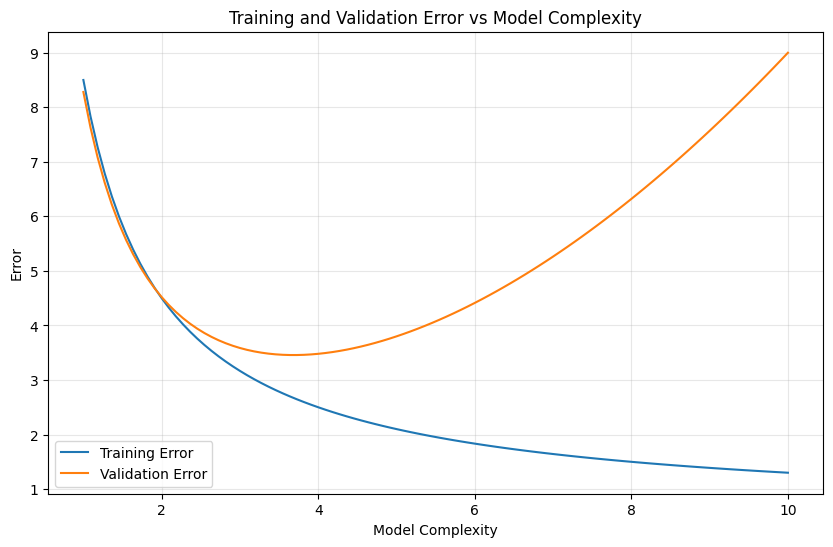

In [1]:
import numpy as np
import matplotlib.pyplot as plt

complexity = np.linspace(1, 10, 100)

bias_squared = 8 / complexity + 0.2
variance = 0.08 * complexity**2

training_error = 8 / complexity + 0.5
validation_error = bias_squared + variance

plt.figure(figsize=(10, 6))

plt.plot(
    complexity,
    training_error,
    label="Training Error"
)

plt.plot(
    complexity,
    validation_error,
    label="Validation Error"
)

plt.xlabel("Model Complexity")
plt.ylabel("Error")
plt.title("Training and Validation Error vs Model Complexity")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 13. Practical Demonstration: Polynomial Regression

Polynomial regression is useful for visualizing the Bias-Variance Tradeoff.

We will create a nonlinear dataset and train polynomial models with different degrees.

A low-degree polynomial may underfit.

A moderate-degree polynomial may capture the underlying relationship well.

A very high-degree polynomial may overfit the training data.

We will compare:

- Training Mean Squared Error
- Validation Mean Squared Error

for different polynomial degrees.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

np.random.seed(42)

X = np.linspace(-3, 3, 100).reshape(-1, 1)

y = (
    0.5 * X[:, 0]**3
    - 2 * X[:, 0]**2
    + X[:, 0]
    + np.random.normal(0, 3, 100)
)

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [3]:
degrees = range(1, 16)

train_errors = []
val_errors = []

for degree in degrees:

    model = Pipeline([
        ("polynomial", PolynomialFeatures(degree=degree)),
        ("regression", LinearRegression())
    ])

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    train_errors.append(
        mean_squared_error(y_train, train_pred)
    )

    val_errors.append(
        mean_squared_error(y_val, val_pred)
    )

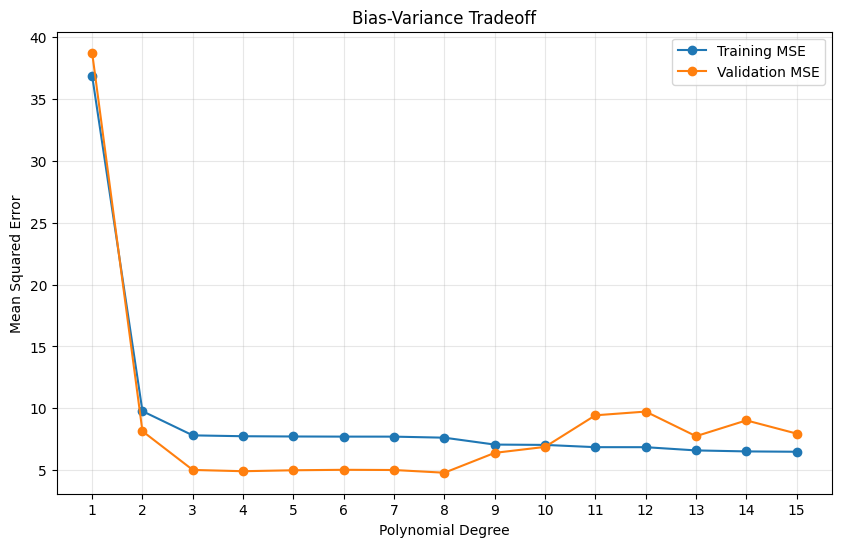

In [4]:
plt.figure(figsize=(10, 6))

plt.plot(
    degrees,
    train_errors,
    marker="o",
    label="Training MSE"
)

plt.plot(
    degrees,
    val_errors,
    marker="o",
    label="Validation MSE"
)

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Bias-Variance Tradeoff")

plt.xticks(list(degrees))
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 14. Finding the Best Complexity

In [5]:
best_degree = degrees[np.argmin(val_errors)]

best_val_error = min(val_errors)

print("Best polynomial degree:", best_degree)
print("Lowest validation MSE:", best_val_error)

Best polynomial degree: 8
Lowest validation MSE: 4.7977389984310905


### Interpretation

The polynomial degree controls model complexity.

A very small degree may produce:

$$
High\ Bias
$$

A very large degree may produce:

$$
High\ Variance
$$

The degree with the lowest validation error provides a useful balance.

This does not mean that the mathematically optimal degree is always the same across datasets.

The best complexity depends on:

- Dataset size
- Noise level
- Feature representation
- Model class
- Regularization
- Data distribution

## 15. Visualizing Underfitting

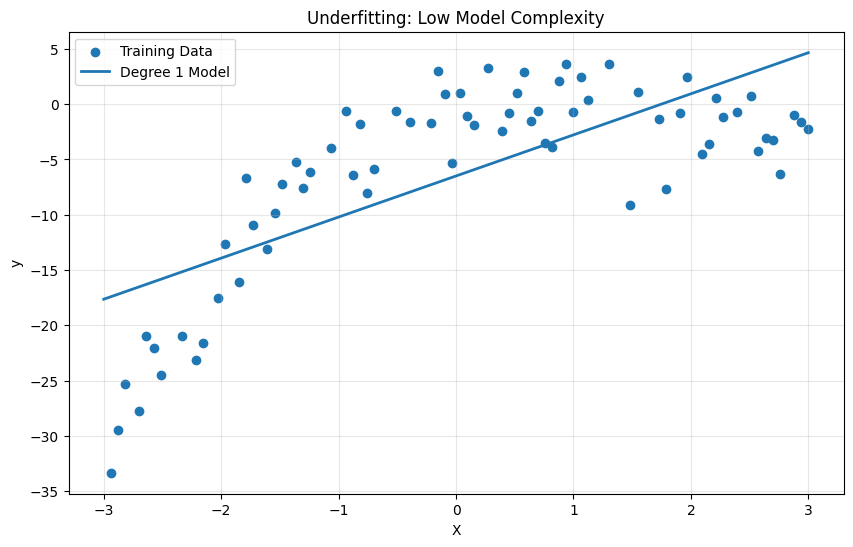

In [6]:
degree = 1

model_underfit = Pipeline([
    ("polynomial", PolynomialFeatures(degree=degree)),
    ("regression", LinearRegression())
])

model_underfit.fit(X_train, y_train)

x_plot = np.linspace(-3, 3, 300).reshape(-1, 1)
y_plot = model_underfit.predict(x_plot)

plt.figure(figsize=(10, 6))

plt.scatter(X_train, y_train, label="Training Data")

plt.plot(
    x_plot,
    y_plot,
    linewidth=2,
    label="Degree 1 Model"
)

plt.xlabel("X")
plt.ylabel("y")
plt.title("Underfitting: Low Model Complexity")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 16. Visualizing a Good Fit

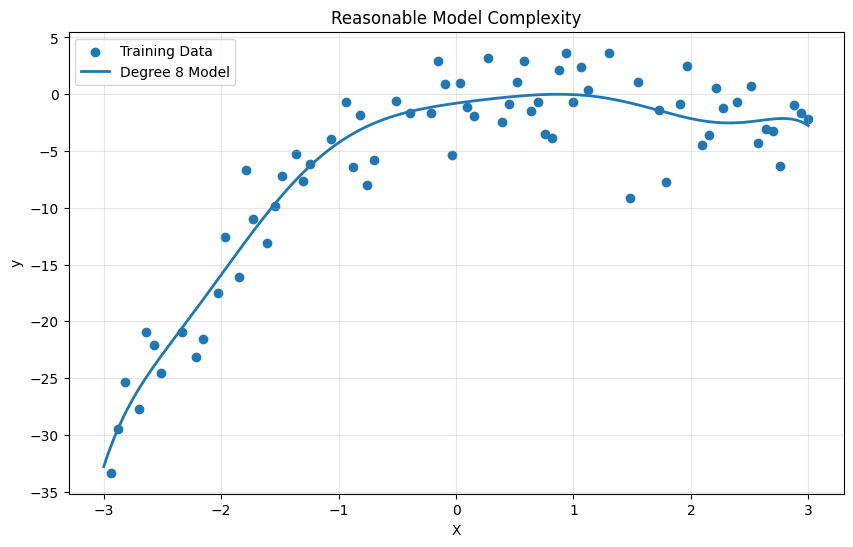

In [7]:
degree = best_degree

model_good = Pipeline([
    ("polynomial", PolynomialFeatures(degree=degree)),
    ("regression", LinearRegression())
])

model_good.fit(X_train, y_train)

y_plot = model_good.predict(x_plot)

plt.figure(figsize=(10, 6))

plt.scatter(X_train, y_train, label="Training Data")

plt.plot(
    x_plot,
    y_plot,
    linewidth=2,
    label=f"Degree {degree} Model"
)

plt.xlabel("X")
plt.ylabel("y")
plt.title("Reasonable Model Complexity")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 17. Visualizing Overfitting

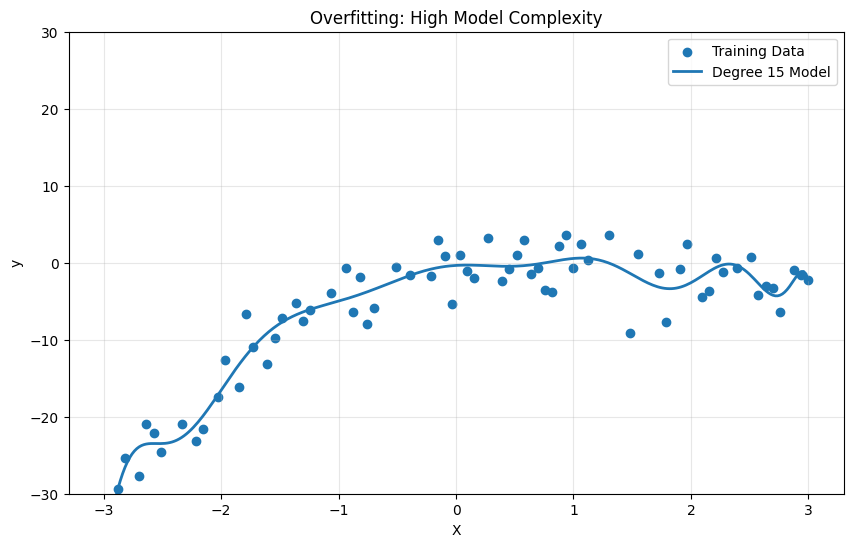

In [8]:
degree = 15

model_overfit = Pipeline([
    ("polynomial", PolynomialFeatures(degree=degree)),
    ("regression", LinearRegression())
])

model_overfit.fit(X_train, y_train)

y_plot = model_overfit.predict(x_plot)

plt.figure(figsize=(10, 6))

plt.scatter(X_train, y_train, label="Training Data")

plt.plot(
    x_plot,
    y_plot,
    linewidth=2,
    label="Degree 15 Model"
)

plt.xlabel("X")
plt.ylabel("y")
plt.title("Overfitting: High Model Complexity")

plt.ylim(-30, 30)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 18. Learning Curves

Learning curves show how model performance changes as the amount of training data increases.

They are useful for diagnosing:

- Underfitting
- Overfitting
- High bias
- High variance

We commonly plot:

- Training error
- Validation error

against the number of training examples.

Learning curves provide a different perspective from the model-complexity curve.

### Typical high-bias pattern

Training and validation errors are both relatively high and converge to similar values.

### Typical high-variance pattern

Training error is low while validation error remains significantly higher.

In [9]:
from sklearn.model_selection import learning_curve

model = Pipeline([
    ("polynomial", PolynomialFeatures(degree=5)),
    ("regression", LinearRegression())
])

train_sizes, train_scores, val_scores = learning_curve(
    model,
    X,
    y,
    cv=5,
    scoring="neg_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42
)

train_mse = -train_scores.mean(axis=1)
val_mse = -val_scores.mean(axis=1)

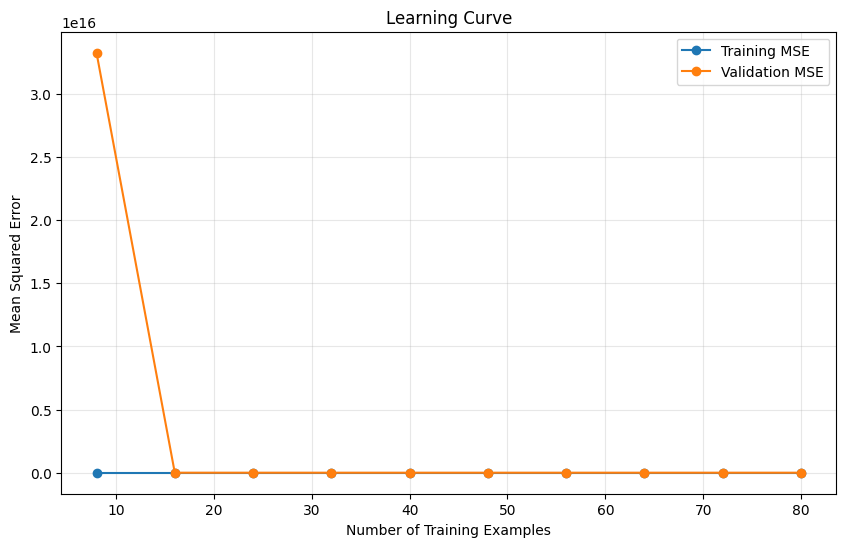

In [10]:
plt.figure(figsize=(10, 6))

plt.plot(
    train_sizes,
    train_mse,
    marker="o",
    label="Training MSE"
)

plt.plot(
    train_sizes,
    val_mse,
    marker="o",
    label="Validation MSE"
)

plt.xlabel("Number of Training Examples")
plt.ylabel("Mean Squared Error")
plt.title("Learning Curve")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 19. Bias-Variance and Regularization

Regularization controls model complexity by penalizing overly complex models.

For example, Ridge Regression minimizes:

$$
\text{MSE} + \lambda \sum_{j=1}^{d} w_j^2
$$

where:

- $\lambda$ = regularization strength
- $w_j$ = model coefficients

Increasing $\lambda$ generally makes the model less flexible.

Therefore:

$$
\lambda \uparrow
\Rightarrow
Complexity \downarrow
\Rightarrow
Bias \uparrow
\Rightarrow
Variance \downarrow
$$

Decreasing $\lambda$ generally makes the model more flexible:

$$
\lambda \downarrow
\Rightarrow
Complexity \uparrow
\Rightarrow
Bias \downarrow
\Rightarrow
Variance \uparrow
$$

Regularization is therefore closely connected to the Bias-Variance Tradeoff.

## 20. Bias-Variance and Cross-Validation

Cross-validation helps us estimate how well a model will generalize to unseen data.

Suppose we are choosing between:

- A simple model
- A moderately complex model
- A highly complex model

Training error alone may favor the most complex model.

However, cross-validation evaluates performance on different validation folds.

The model with the best cross-validation performance is often a better choice for generalization.

This is one reason cross-validation is widely used for:

- Model selection
- Hyperparameter tuning
- Comparing model complexity
- Selecting regularization strength

## 21. Effect of More Training Data

Increasing the amount of training data can often reduce variance.

A high-variance model may fit the particular training dataset too closely.

With more representative examples, the model has more information about the underlying distribution.

Therefore, in many practical situations:

$$
More\ Data
\rightarrow
Lower\ Variance
\rightarrow
Better\ Generalization
$$

However, additional data does not automatically solve every problem.

If a model has very high bias, simply adding more data may not significantly improve its ability to represent the underlying relationship.

For high-bias models, increasing model capacity or improving features may be more useful.

## 22. Diagnosing Bias and Variance

| Situation | Training Error | Validation Error | Likely Problem |
|---|---:|---:|---|
| Both high | High | High | High Bias |
| Training low, validation high | Low | High | High Variance |
| Both low | Low | Low | Good Generalization |
| Large gap between training and validation | Very Low | Much Higher | Possible Overfitting |

### High Bias

Possible solutions:

- Increase model complexity
- Add useful features
- Reduce regularization
- Use a more expressive model

### High Variance

Possible solutions:

- Get more training data
- Reduce model complexity
- Increase regularization
- Perform feature selection
- Use cross-validation
- Reduce noise or improve data quality

## 23. Bias-Variance vs Underfitting-Overfitting

These concepts are closely related but are not exactly identical.

### Underfitting

Usually associated with:

$$
High\ Bias
$$

The model is too simple to capture the underlying structure.

### Overfitting

Usually associated with:

$$
High\ Variance
$$

The model is too sensitive to the training data.

Therefore:

$$
Underfitting
\approx
High\ Bias
$$

and:

$$
Overfitting
\approx
High\ Variance
$$

These are useful practical interpretations, but bias and variance are more precise statistical concepts.

## 24. Important Misconception

A common misconception is:

> "The best model is the one with the lowest training error."

This is incorrect.

A sufficiently flexible model can often reduce training error dramatically.

For example:

$$
Training\ Error \rightarrow 0
$$

does not guarantee:

$$
Test\ Error \rightarrow 0
$$

The real objective is good performance on unseen data.

Therefore, we care about:

$$
Generalization\ Error
$$

rather than training error alone.

## 25. Practical Workflow for Managing Bias and Variance

When building a machine learning model:

### Step 1: Establish a baseline

Train a simple model and measure its performance.

### Step 2: Compare training and validation performance

Look for signs of underfitting or overfitting.

### Step 3: Increase model complexity gradually

Observe how training and validation performance change.

### Step 4: Tune hyperparameters

Use validation data or cross-validation.

### Step 5: Apply regularization when necessary

Regularization can control excessive model complexity.

### Step 6: Evaluate on the test set

The test set should be used only after model selection and tuning.

### Step 7: Prefer generalization over memorization

The final model should perform well on data it has never seen.

## 26. Complete Mental Model

Think about model complexity as a spectrum.

### Very Simple Model

$$
Bias \uparrow
$$

$$
Variance \downarrow
$$

Result:

**Underfitting**

---

### Appropriate Complexity

$$
Bias \downarrow
$$

$$
Variance\ is\ controlled
$$

Result:

**Good Generalization**

---

### Very Complex Model

$$
Bias \downarrow
$$

$$
Variance \uparrow
$$

Result:

**Overfitting**

---

The objective is to find the region where the model has enough complexity to capture the important structure without becoming excessively sensitive to the training data.

## 27. Key Formulas

### Bias

$$
Bias(\hat{f}(x))
=
E[\hat{f}(x)] - f(x)
$$

### Squared Bias

$$
Bias^2
=
\left(E[\hat{f}(x)] - f(x)\right)^2
$$

### Variance

$$
Variance(\hat{f}(x))
=
E
\left[
\left(
\hat{f}(x)-E[\hat{f}(x)]
\right)^2
\right]
$$

### Bias-Variance Decomposition

$$
Expected\ Error
=
Bias^2 + Variance + Noise
$$

### Regression Data-Generating Process

$$
Y = f(X) + \epsilon
$$

These formulas provide the mathematical foundation for understanding model generalization.

# 28. Final Summary

## Bias

Bias represents systematic error caused by overly strong assumptions.

High bias usually leads to:

**Underfitting**

---

## Variance

Variance represents sensitivity to the particular training dataset.

High variance usually leads to:

**Overfitting**

---

## Bias-Variance Tradeoff

Increasing model complexity generally:

$$
Bias \downarrow
$$

$$
Variance \uparrow
$$

Decreasing model complexity generally:

$$
Bias \uparrow
$$

$$
Variance \downarrow
$$

---

## Total Expected Error

$$
Expected\ Error
=
Bias^2 + Variance + Irreducible\ Noise
$$

---

## Main Goal

The objective of machine learning is not:

$$
Minimum\ Training\ Error
$$

The objective is:

$$
Good\ Generalization\ to\ Unseen\ Data
$$

A strong model achieves a useful balance between bias and variance while controlling overfitting.